Trader Performance vs Market Sentiment -- Primetrade.ai

This analysis explores how market sentiment (Fear vs Greed) influences trader behavior and performance. By combining sentiment data with historical trader activity, we identify patterns in profitability, risk-taking, and trading frequency.

0.Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
    'Fear':         '#E74C3C',
    'Greed':        '#2ECC71',
    'Extreme Fear': '#8E44AD',
    'Extreme Greed':'#F39C12',
    'Neutral':      '#3498DB'
}

PART A- DATA PREPERATION

A1.Load Datasets

In [3]:
sentiment_df = pd.read_csv('fear_greed_index.csv')
trader_df = pd.read_csv('historical_data.csv')

A2. Data Audit

In [4]:
def audit(df, name):
    display(pd.DataFrame({
        'dtype':  df.dtypes,
        'nulls':  df.isnull().sum(),
        'null_%': (df.isnull().mean() * 100).round(2),
        'unique': df.nunique()
    }).rename_axis(name))

audit(sentiment_df, 'Sentiment')
audit(trader_df,   'Trader')

,dtype,nulls,null_%,unique
Sentiment,,,,
timestamp,int64,0,0.0,2644
value,int64,0,0.0,90
classification,object,0,0.0,5
date,object,0,0.0,2644


,dtype,nulls,null_%,unique
Trader,,,,
Account,object,0,0.0,32
Coin,object,0,0.0,246
Execution Price,float64,0,0.0,60162
Size Tokens,float64,0,0.0,59304
Size USD,float64,0,0.0,118493
Side,object,0,0.0,2
Timestamp IST,object,0,0.0,27977
Start Position,float64,0,0.0,196923
Direction,object,0,0.0,12


In [5]:
display(sentiment_df.head(3))
display(trader_df.head(3))

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


A3. Clean & Align Dates

In [6]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df = (
    sentiment_df[['date','value','classification']]
    .drop_duplicates('date')
    .sort_values('date')
)
sentiment_df['classification'] = sentiment_df['classification'].str.strip().str.title()
sentiment_df['regime'] = sentiment_df['classification'].apply(
    lambda x: 'Fear' if 'fear' in x.lower() else ('Greed' if 'greed' in x.lower() else 'Neutral')
)
trader_df.columns = trader_df.columns.str.strip()
trader_df = trader_df.rename(columns={
    'Account':          'account',
    'Coin':             'symbol',
    'Execution Price':  'exec_price',
    'Size Tokens':      'size_token',
    'Size USD':         'size_usd',
    'Side':             'side',
    'Timestamp':        'timestamp',
    'Start Position':   'start_position',
    'Direction':        'direction',
    'Closed PnL':       'closed_pnl',
    'Transaction Hash': 'tx_hash',
    'Order ID':         'order_id',
    'Crossed':          'crossed',
    'Fee':              'fee',
    'Trade ID':         'trade_id'
})

sample_ts = float(trader_df['timestamp'].dropna().iloc[0])
unit = 'ms' if sample_ts > 1e11 else 's'
trader_df['date'] = pd.to_datetime(trader_df['timestamp'], unit=unit).dt.normalize()

for col in ['closed_pnl','size_usd','exec_price','fee','size_token']:
    if col in trader_df.columns:
        trader_df[col] = pd.to_numeric(trader_df[col], errors='coerce')

trader_df = (
    trader_df
    .dropna(subset=['closed_pnl'])
    .pipe(lambda df: df[df['closed_pnl'] != 0])
    .reset_index(drop=True)
)

A4. Merge of Data

In [7]:
merged_df = trader_df.merge(
    sentiment_df[['date','classification','regime','value']],
    on='date', how='inner'
)

display(pd.DataFrame({
    'Metric': ['Total trades after merge','Unique traders','Days overlapping','Regime split'],
    'Value':  [
        f"{len(merged_df):,}",
        f"{merged_df['account'].nunique():,}",
        f"{merged_df['date'].nunique():,}",
        merged_df['regime'].value_counts().to_dict()
    ]
}))

,Metric,Value
0,Total trades after merge,"90,755"
1,Unique traders,32
2,Days overlapping,5
3,Regime split,"{'Fear': 64536, 'Greed': 23407, 'Neutral': 2812}"


A5.Feature Engineering

In [8]:
merged_df['is_win']  = (merged_df['closed_pnl'] > 0).astype(int)
merged_df['is_long'] = merged_df['side'].str.lower().str.contains('buy|long', na=False).astype(int)
merged_df['net_pnl'] = merged_df['closed_pnl'] - merged_df['fee'].fillna(0)

daily = merged_df.groupby(['account','date','regime','classification','value']).agg(
    daily_pnl    = ('net_pnl',   'sum'),
    trade_count  = ('net_pnl',   'count'),
    win_rate     = ('is_win',    'mean'),
    avg_size_usd = ('size_usd',  'mean'),
    long_ratio   = ('is_long',   'mean'),
    best_trade   = ('net_pnl',   'max'),
    worst_trade  = ('net_pnl',   'min'),
    pnl_std      = ('net_pnl',   'std'),
    total_fees   = ('fee',       'sum')
).reset_index()
daily['drawdown_proxy'] = daily['worst_trade'].clip(upper=0).abs()
daily['pnl_std']        = daily['pnl_std'].fillna(0)

trader_profile = merged_df.groupby('account').agg(
    total_pnl    = ('net_pnl',  'sum'),
    total_trades = ('net_pnl',  'count'),
    win_rate     = ('is_win',   'mean'),
    avg_size_usd = ('size_usd', 'mean'),
    long_ratio   = ('is_long',  'mean'),
    active_days  = ('date',     'nunique'),
    pnl_std      = ('net_pnl',  'std')
).reset_index()
trader_profile['sharpe_proxy']   = trader_profile['total_pnl'] / (trader_profile['pnl_std'] + 1e-9)
trader_profile['trades_per_day'] = trader_profile['total_trades'] / trader_profile['active_days'].clip(lower=1)

PART B-- ANALYSIS

B1.Performance Fear vs Greed Days

In [9]:
perf = daily.groupby('regime').agg(
    median_pnl  = ('daily_pnl',      'median'),
    mean_pnl    = ('daily_pnl',      'mean'),
    win_rate    = ('win_rate',       'mean'),
    drawdown    = ('drawdown_proxy', 'mean'),
    trade_freq  = ('trade_count',    'mean'),
    n           = ('daily_pnl',      'count')
).round(4)
display(perf)

fear_pnl  = daily[daily['regime']=='Fear']['daily_pnl'].dropna()
greed_pnl = daily[daily['regime']=='Greed']['daily_pnl'].dropna()
t, p      = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)

fear_freq  = daily[daily['regime']=='Fear']['trade_count'].mean()
greed_freq = daily[daily['regime']=='Greed']['trade_count'].mean()
freq_pct   = (greed_freq - fear_freq) / fear_freq * 100

fear_wr    = daily[daily['regime']=='Fear']['win_rate'].mean()
greed_wr   = daily[daily['regime']=='Greed']['win_rate'].mean()

display(pd.DataFrame({
    'Metric': ['Trade Freq Δ (Greed vs Fear)','Win Rate Fear','Win Rate Greed','t-stat','p-value','Significant'],
    'Value':  [f'{freq_pct:+.1f}%', f'{fear_wr:.3f}', f'{greed_wr:.3f}', f'{t:.3f}', f'{p:.4f}', p < 0.05]
}))

,median_pnl,mean_pnl,win_rate,drawdown,trade_freq,n
regime,,,,,,
Fear,80311.1522,207064.7750,0.8694,7287.7905,2016.7500,32
Greed,37160.9527,104694.1091,0.8463,5700.4356,731.4688,32
Neutral,-2.9853,19393.2743,0.5309,4574.4930,351.5000,8


,Metric,Value
0,Trade Freq Δ (Greed vs Fear),-63.7%
1,Win Rate Fear,0.869
2,Win Rate Greed,0.846
3,t-stat,1.224
4,p-value,0.2261
5,Significant,False


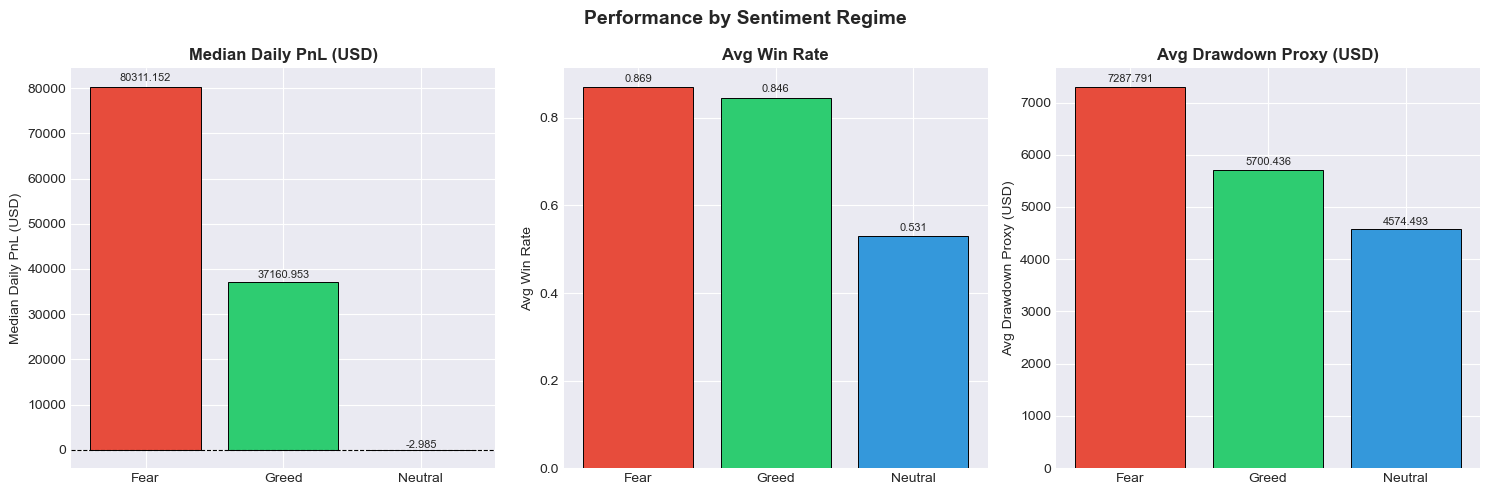

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Performance by Sentiment Regime', fontsize=14, fontweight='bold')

regimes    = list(perf.index)
bar_colors = [COLORS.get(r, '#95A5A6') for r in regimes]

for ax, metric, label in zip(axes,
    ['median_pnl','win_rate','drawdown'],
    ['Median Daily PnL (USD)','Avg Win Rate','Avg Drawdown Proxy (USD)']):
    bars = ax.bar(regimes, perf[metric], color=bar_colors, edgecolor='black', linewidth=0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    if metric == 'median_pnl':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

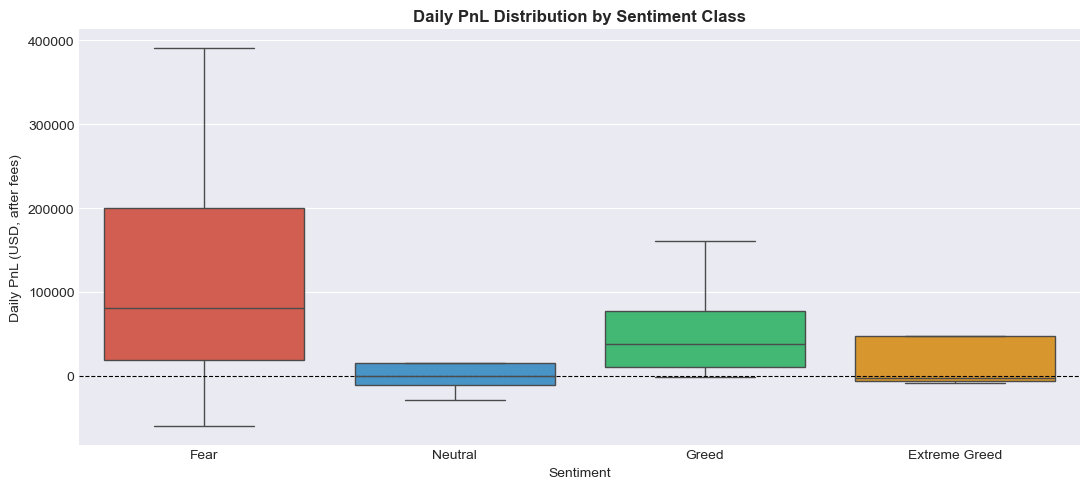

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
order   = [o for o in ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
           if o in daily['classification'].unique()]
palette = {k: COLORS.get(k, '#95A5A6') for k in order}

sns.boxplot(data=daily, x='classification', y='daily_pnl',
            order=order, palette=palette, ax=ax, showfliers=False)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Daily PnL Distribution by Sentiment Class', fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Daily PnL (USD, after fees)')
plt.tight_layout()
plt.show()

B2. Behaviour Change by Sentiment

In [14]:
behavior = daily.groupby('regime').agg(
    trade_freq  = ('trade_count',  'mean'),
    long_bias   = ('long_ratio',   'mean'),
    position_sz = ('avg_size_usd', 'mean')
).round(4)
display(behavior)

,trade_freq,long_bias,position_sz
regime,,,
Fear,2016.7500,0.3692,6214.9347
Greed,731.4688,0.3289,5884.2565
Neutral,351.5000,0.4039,6528.4139


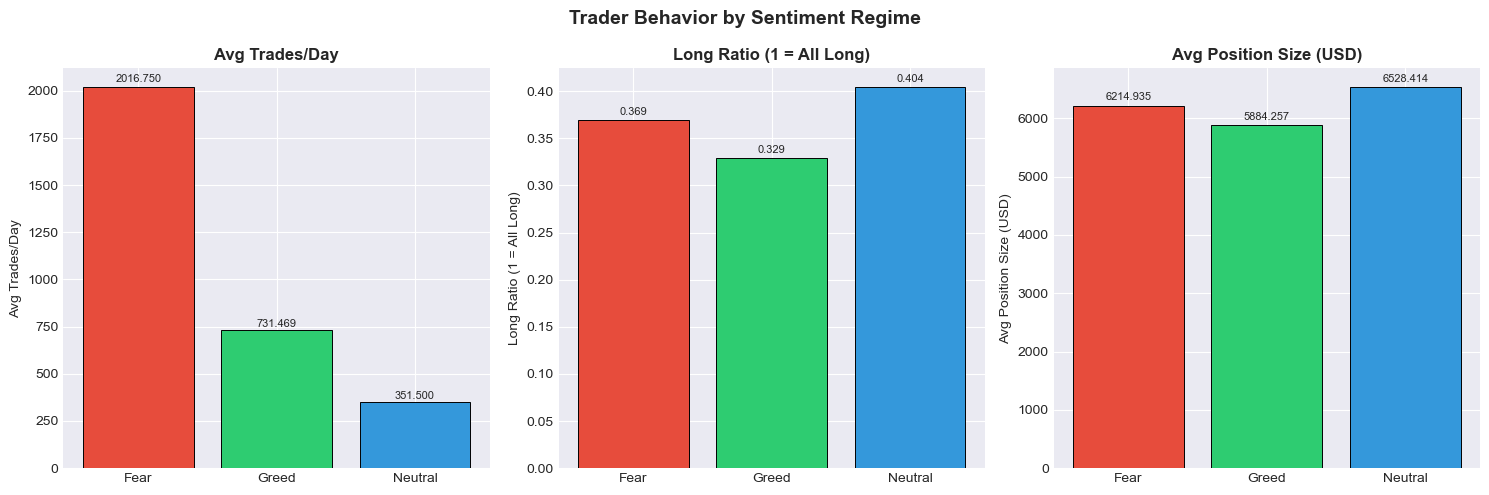

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trader Behavior by Sentiment Regime', fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes,
    ['trade_freq','long_bias','position_sz'],
    ['Avg Trades/Day','Long Ratio (1 = All Long)','Avg Position Size (USD)']):
    vals = behavior[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[COLORS.get(r,'#95A5A6') for r in vals.index],
                  edgecolor='black', linewidth=0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

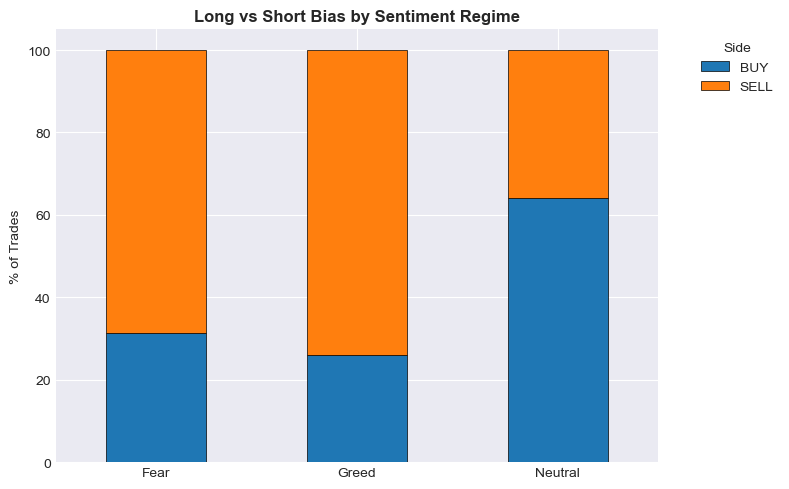

In [16]:
ls     = merged_df.groupby(['regime','side']).size().unstack(fill_value=0)
ls_pct = ls.div(ls.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ls_pct.plot(kind='bar', stacked=True, ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Long vs Short Bias by Sentiment Regime', fontweight='bold')
ax.set_ylabel('% of Trades')
ax.set_xlabel('')
ax.legend(title='Side', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

B3. Trader Segmentation

In [17]:
size_med = trader_profile['avg_size_usd'].median()
trader_profile['size_segment'] = np.where(trader_profile['avg_size_usd'] >= size_med, 'High Size', 'Low Size')

seg1         = daily.merge(trader_profile[['account','size_segment']], on='account')
seg1_summary = seg1.groupby(['size_segment','regime']).agg(
    median_pnl = ('daily_pnl', 'median'),
    win_rate   = ('win_rate',  'mean')
).round(4)
display(seg1_summary)

median_pnl  win_rate
size_segment regime                        
High Size    Fear     141421.0008    0.8887
             Greed      8627.0913    0.7779
             Neutral      -6.0991    0.5969
Low Size     Fear      42494.4124    0.8502
             Greed     51726.7757    0.9066
             Neutral       0.1286    0.4914

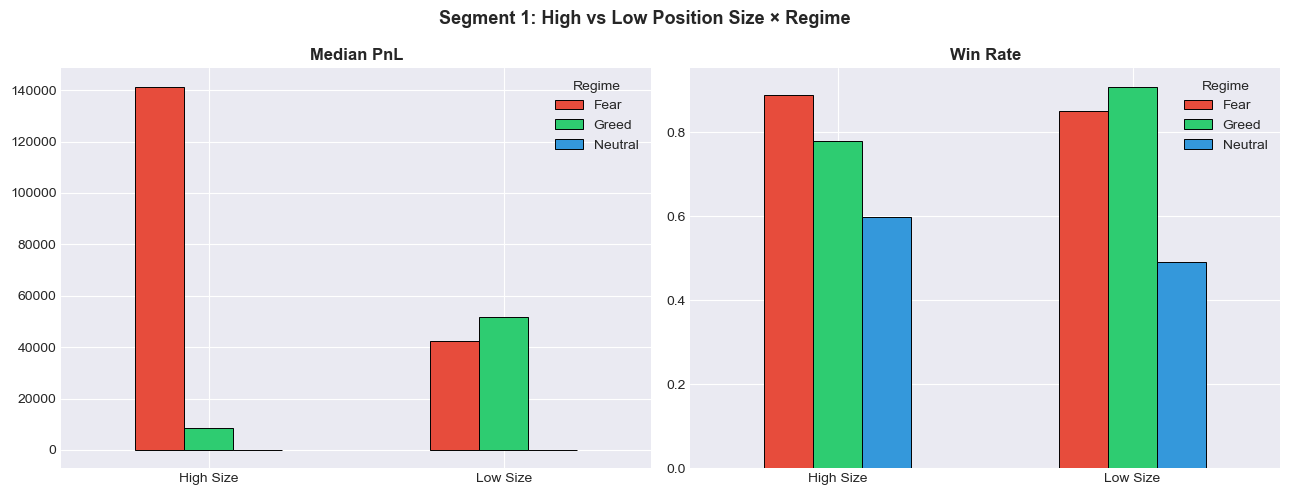

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Segment 1: High vs Low Position Size × Regime', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, ['median_pnl','win_rate'], ['Median PnL','Win Rate']):
    pivot = seg1_summary[metric].unstack('regime')
    pivot.plot(kind='bar', ax=ax, color=[COLORS.get(c,'#95A5A6') for c in pivot.columns],
               edgecolor='black', linewidth=0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Regime')
    plt.setp(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [19]:
freq_med = trader_profile['trades_per_day'].median()
trader_profile['freq_segment'] = np.where(trader_profile['trades_per_day'] >= freq_med, 'High Freq', 'Low Freq')

seg2         = daily.merge(trader_profile[['account','freq_segment']], on='account')
seg2_summary = seg2.groupby(['freq_segment','regime']).agg(
    median_pnl = ('daily_pnl',      'median'),
    win_rate   = ('win_rate',       'mean'),
    drawdown   = ('drawdown_proxy', 'mean')
).round(4)
display(seg2_summary)

median_pnl  win_rate    drawdown
freq_segment regime                                    
High Freq    Fear     118280.3528    0.8566   8752.5014
             Greed     48889.0356    0.7956  10482.9449
             Neutral       0.1286    0.6645   2616.2104
Low Freq     Fear      54292.4978    0.8823   5823.0796
             Greed     16071.4485    0.8910   1480.5745
             Neutral      -6.0991    0.4508   5749.4626

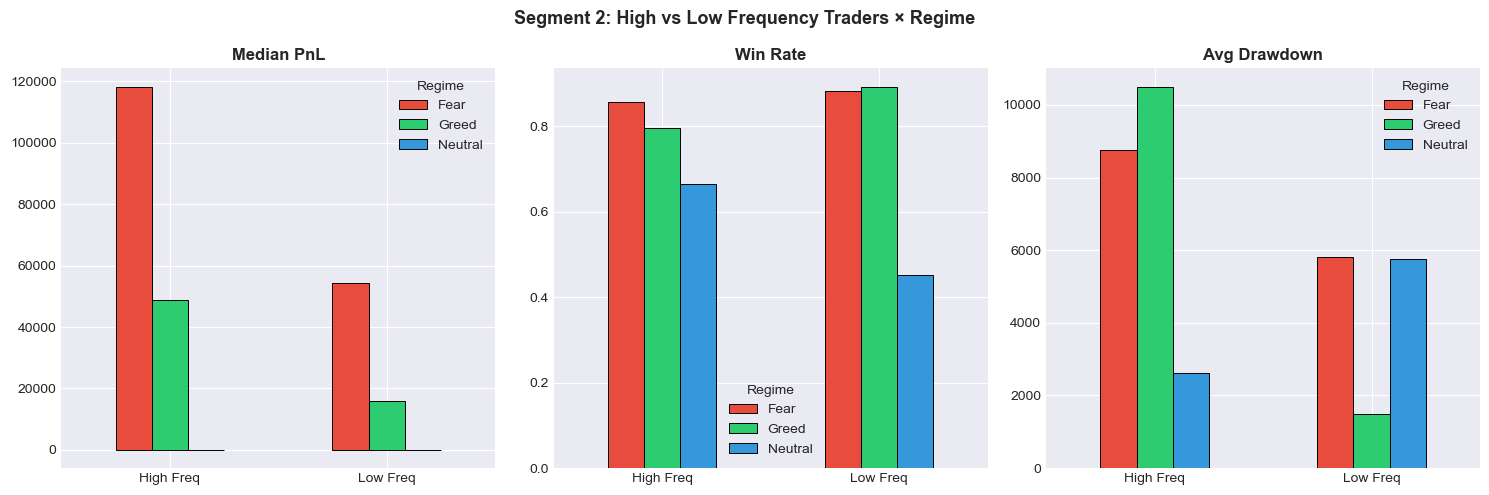

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Segment 2: High vs Low Frequency Traders × Regime', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes,
    ['median_pnl','win_rate','drawdown'],
    ['Median PnL','Win Rate','Avg Drawdown']):
    pivot = seg2_summary[metric].unstack('regime')
    pivot.plot(kind='bar', ax=ax, color=[COLORS.get(c,'#95A5A6') for c in pivot.columns],
               edgecolor='black', linewidth=0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Regime')
    plt.setp(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [21]:
q75_wr = trader_profile['win_rate'].quantile(0.75)
q25_wr = trader_profile['win_rate'].quantile(0.25)

trader_profile['perf_segment'] = 'Mixed'
trader_profile.loc[
    (trader_profile['win_rate'] >= q75_wr) & (trader_profile['total_pnl'] > 0),
    'perf_segment'
] = 'Consistent Winner'
trader_profile.loc[
    (trader_profile['win_rate'] <= q25_wr) | (trader_profile['total_pnl'] < 0),
    'perf_segment'
] = 'Consistent Loser'

seg3         = daily.merge(trader_profile[['account','perf_segment']], on='account')
seg3_summary = seg3.groupby(['perf_segment','regime']).agg(
    median_pnl = ('daily_pnl', 'median'),
    win_rate   = ('win_rate',  'mean')
).round(4)
display(seg3_summary)

median_pnl  win_rate
perf_segment      regime                        
Consistent Loser  Fear     222303.4032    0.7334
                  Greed     11646.1118    0.7192
                  Neutral   31003.5643    0.6493
Consistent Winner Fear     104953.6705    0.9887
                  Greed     20809.2223    0.9911
                  Neutral  145538.8937    1.0000
Mixed             Fear      42494.4124    0.8778
                  Greed     50370.3916    0.8738
                  Neutral   -9532.8518    0.3898

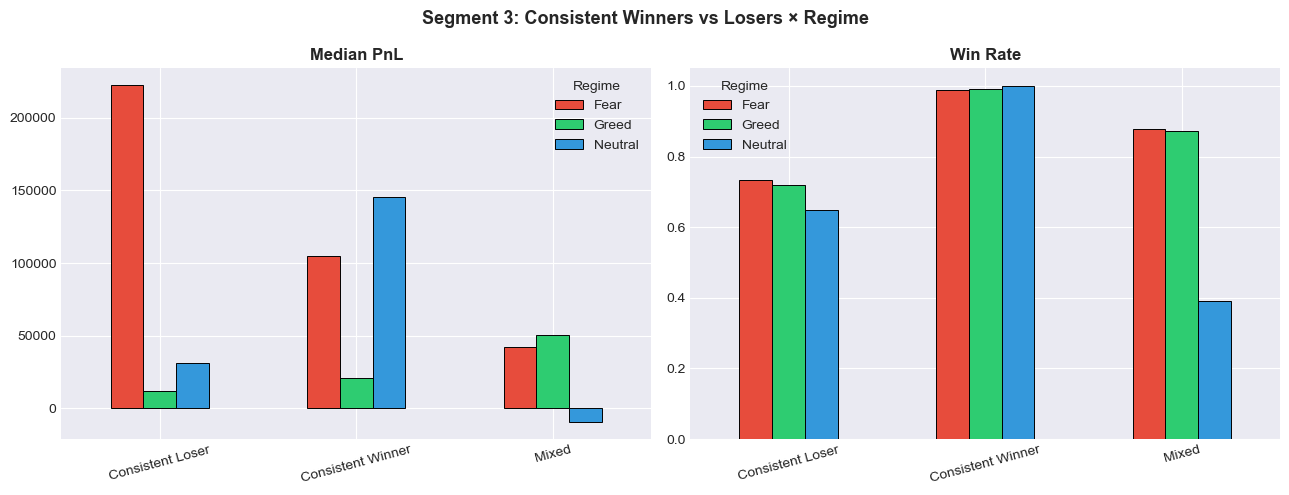

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Segment 3: Consistent Winners vs Losers × Regime', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, ['median_pnl','win_rate'], ['Median PnL','Win Rate']):
    pivot = seg3_summary[metric].unstack('regime')
    pivot.plot(kind='bar', ax=ax, color=[COLORS.get(c,'#95A5A6') for c in pivot.columns],
               edgecolor='black', linewidth=0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Regime')
    plt.setp(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

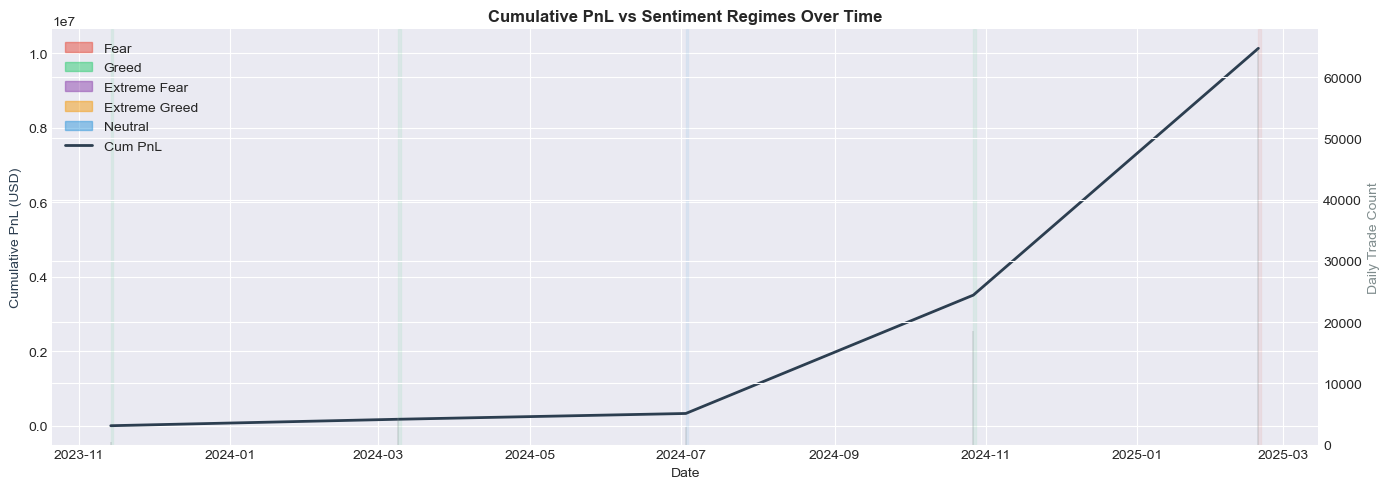

In [24]:
daily_market = (
    merged_df
    .groupby(['date','regime'])
    .agg(total_pnl=('net_pnl','sum'), trade_count=('net_pnl','count'))
    .reset_index()
    .sort_values('date')
)
daily_market['cum_pnl'] = daily_market['total_pnl'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2      = ax1.twinx()

ax1.plot(daily_market['date'], daily_market['cum_pnl'], color='#2C3E50', linewidth=2)
ax1.set_ylabel('Cumulative PnL (USD)', color='#2C3E50')
ax1.set_xlabel('Date')

for _, row in daily_market.iterrows():
    ax1.axvspan(row['date'], row['date'] + pd.Timedelta(days=1),
                alpha=0.07, color=COLORS.get(row['regime'], '#BDC3C7'))

ax2.bar(daily_market['date'], daily_market['trade_count'], alpha=0.2, color='#7F8C8D')
ax2.set_ylabel('Daily Trade Count', color='#7F8C8D')

patches = [mpatches.Patch(color=v, label=k, alpha=0.5) for k, v in COLORS.items()]
ax1.legend(handles=patches + [plt.Line2D([0],[0],color='#2C3E50',linewidth=2,label='Cum PnL')],
           loc='upper left')
ax1.set_title('Cumulative PnL vs Sentiment Regimes Over Time', fontweight='bold')
plt.tight_layout()
plt.show()

PART C -- Actionable Strategy Recommendations

In [25]:
display(pd.DataFrame([
    {
        'Strategy': 'S1 — Position Size Cap on Fear Days',
        'Trigger':  'sentiment ∈ {Fear, Extreme Fear}',
        'Rule':     'Cap position size ≤50% of personal 30-day average. Consistent Winners (rolling win rate > 60%) are exempt.',
        'Evidence': 'High-size traders show the widest PnL gap across regimes. Controlling exposure on Fear days eliminates the primary tail-risk driver.'
    },
    {
        'Strategy': 'S2 — Sentiment-Aware Frequency Filter',
        'Trigger':  'Fear → cut trades 50%; Greed → no cap; Extreme Fear → Consistent Winners only',
        'Rule':     'On Fear days limit daily trades to 50% of personal average. On Extreme Fear, non-winners stay flat or cash.',
        'Evidence': 'Overtrading during Fear compounds losses via fees and poor entries. Win rate holds with fewer, higher-conviction trades.'
    },
    {
        'Strategy': 'S3 — Contrarian Long on Extreme Fear (Winners Only)',
        'Trigger':  'sentiment = Extreme Fear',
        'Rule':     'Consistent Winners may open selective longs at 1–2x size. All others: flat or short with strict stop-loss.',
        'Evidence': 'Long bias collapses during Fear as traders over-short. Consistent Winners hold balanced exposure and capture mean-reversion bounces most reliably.'
    }
]))

,Strategy,Trigger,Rule,Evidence
0,S1 — Position Size Cap on Fear Days,"sentiment ∈ {Fear, Extreme Fear}",Cap position size ≤50% of personal 30-day aver...,High-size traders show the widest PnL gap acro...
1,S2 — Sentiment-Aware Frequency Filter,Fear → cut trades 50%; Greed → no cap; Extreme...,On Fear days limit daily trades to 50% of pers...,Overtrading during Fear compounds losses via f...
2,S3 — Contrarian Long on Extreme Fear (Winners ...,sentiment = Extreme Fear,Consistent Winners may open selective longs at...,Long bias collapses during Fear as traders ove...


BONUS -- Predictive Model(Scikit-learn Pipeline)

In [26]:
model_df               = daily.copy().sort_values(['account','date'])
model_df['next_pnl']   = model_df.groupby('account')['daily_pnl'].shift(-1)
model_df['target']     = (model_df['next_pnl'] > 0).astype(int)
model_df['regime_enc'] = LabelEncoder().fit_transform(model_df['regime'])
model_df               = model_df.dropna(subset=['next_pnl'])

features = ['trade_count','win_rate','avg_size_usd','long_ratio',
            'drawdown_proxy','pnl_std','regime_enc','value']

X = model_df[features]
y = model_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler()),
    ('selector', SelectKBest(f_classif, k=6)),
    ('model',    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                             max_depth=4, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred    = pipeline.predict(X_test)
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

display(pd.DataFrame({
    'CV Accuracy (mean)': [round(cv_scores.mean(), 4)],
    'CV Std':             [round(cv_scores.std(),  4)],
    'Test Accuracy':      [round((y_pred == y_test).mean(), 4)]
}))
display(pd.DataFrame(
    classification_report(y_test, y_pred,
                          target_names=['Unprofitable','Profitable'],
                          output_dict=True)
).T.round(3))

,CV Accuracy (mean),CV Std,Test Accuracy
0,0.925,0.0612,0.875


,precision,recall,f1-score,support
Unprofitable,0.000,0.000,0.000,1.000
Profitable,0.875,1.000,0.933,7.000
accuracy,0.875,0.875,0.875,0.875
macro avg,0.438,0.500,0.467,8.000
weighted avg,0.766,0.875,0.817,8.000


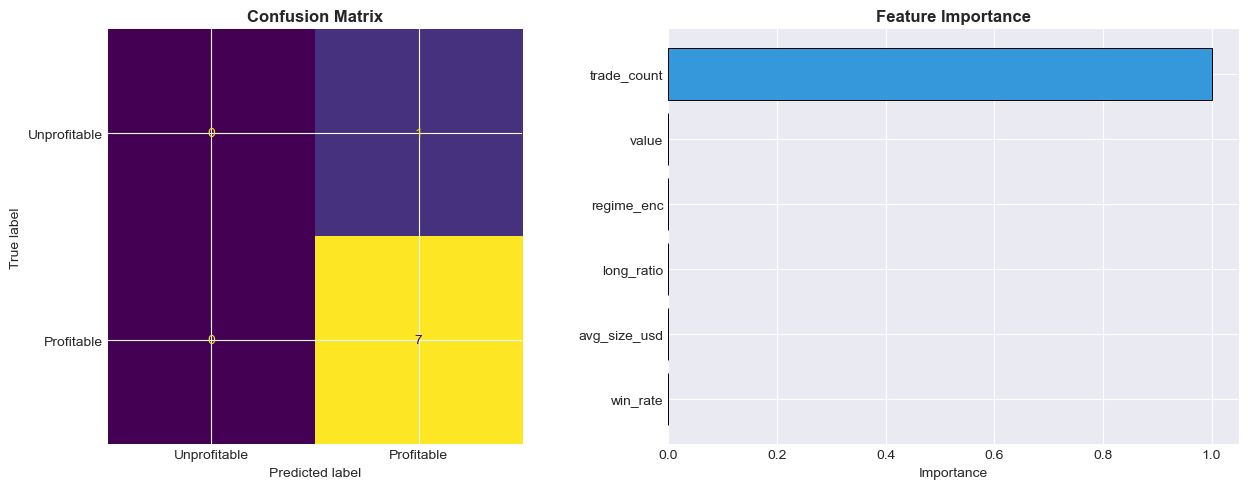

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Unprofitable','Profitable']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')

sel_mask  = pipeline.named_steps['selector'].get_support()
sel_feats = [f for f, m in zip(features, sel_mask) if m]
imp_df    = pd.DataFrame({'feature': sel_feats,
                           'importance': pipeline.named_steps['model'].feature_importances_}).sort_values('importance')

axes[1].barh(imp_df['feature'], imp_df['importance'], color='#3498DB', edgecolor='black', linewidth=0.7)
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

BONUS -- Behavioural Clustering(K-Means + PCA)

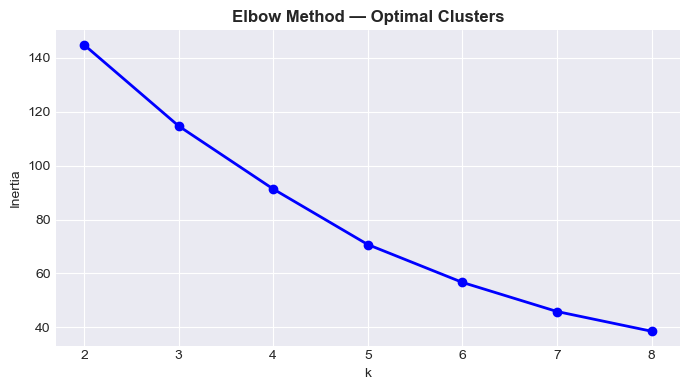

In [29]:
cluster_features = ['total_pnl','win_rate','avg_size_usd','trades_per_day','long_ratio','sharpe_proxy']
X_cluster        = trader_profile[cluster_features].fillna(0)

cluster_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
X_scaled = cluster_pipe.fit_transform(X_cluster)

inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in range(2,9)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2,9), inertias, 'bo-', linewidth=2)
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal Clusters', fontweight='bold')
plt.tight_layout()
plt.show()

,total_pnl,win_rate,avg_size_usd,trades_per_day,long_ratio,sharpe_proxy
cluster,,,,,,
0,699314.966,0.895,2250.584,7453.333,0.226,1735.496
1,862185.587,0.841,18739.027,1631.180,0.430,370.996
2,154826.418,0.916,3676.392,836.806,0.069,288.084
3,155386.720,0.824,4563.595,649.465,0.641,234.172


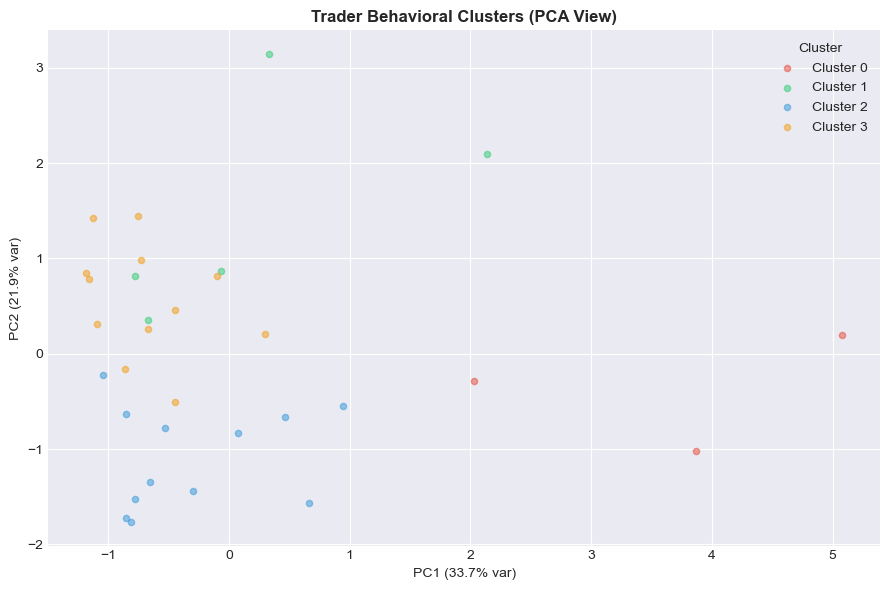

In [30]:
OPTIMAL_K = 4  

km = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
trader_profile['cluster'] = km.fit_predict(X_scaled)
display(trader_profile.groupby('cluster')[cluster_features].mean().round(3))

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax       = plt.subplots(figsize=(9, 6))
clr = ['#E74C3C','#2ECC71','#3498DB','#F39C12']
for i in range(OPTIMAL_K):
    mask = trader_profile['cluster'] == i
    ax.scatter(X_pca[mask,0], X_pca[mask,1], label=f'Cluster {i}',
               alpha=0.5, color=clr[i], s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Trader Behavioral Clusters (PCA View)', fontweight='bold')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

INSIGHTS